# Exploratory Data Analysis

**Dataset:** Credit Card Fraud Detection  
**Target:** `Class` (0 = Legitimate, 1 = Fraud)  
**Goal:** Understand data structure, distributions, and feature–target relationships before model training.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.loader import load_csv


# Add src/ to the path when the package is not installed in editable mode
_src = Path('..').resolve() / 'src'
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

FILENAME = 'creditcard.csv'
TARGET   = 'Class'
print('Imports OK')

Imports OK


## 1. Overview

Load the raw dataset and inspect its shape, column names, data types, and first few rows.

In [ ]:
# load file name present in data folder using a customized function in loader module
df = load_csv(FILENAME)

print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print('\nColumn dtypes:')
print(df.dtypes.to_string())
print('\nFirst 5 rows:')
df.head()

Shape: 284,807 rows x 31 columns

Column dtypes:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Target Analysis

Examine the class distribution of the target variable `Class` (0 = Legitimate, 1 = Fraud).

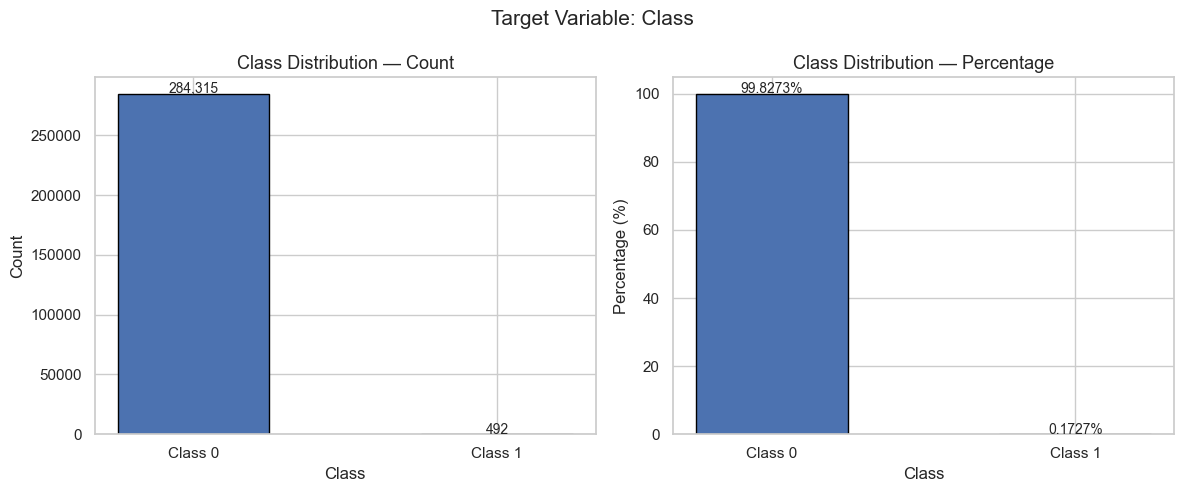

Class counts:
Class
0    284315
1       492

Class percentages:
Class
0    99.8273
1     0.1727


In [ ]:
# check the distribution of teh target column
target_counts = df[TARGET].value_counts().sort_index()
target_pct    = (target_counts / len(df) * 100).round(4)

bar_colors = ['#4C72B0', '#DD8452']
x_labels   = [f'Class {k}' for k in target_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- count bar ---
axes[0].bar(x_labels, target_counts.values, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Count', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v * 1.005, f'{v:,}', ha='center', fontsize=10)

# --- percentage bar ---
axes[1].bar(x_labels, target_pct.values, color=bar_colors, edgecolor='black', width=0.5)
axes[1].set_title('Class Distribution — Percentage', fontsize=13)
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Percentage (%)')
for i, v in enumerate(target_pct.values):
    axes[1].text(i, v * 1.005, f'{v:.4f}%', ha='center', fontsize=10)

plt.suptitle(f'Target Variable: {TARGET}', fontsize=15)
plt.tight_layout()
plt.show()

print('Class counts:')
print(target_counts.to_string())
print('\nClass percentages:')
print(target_pct.to_string())

## 3. Missing Values

Heatmap showing the percentage of null values in each column.

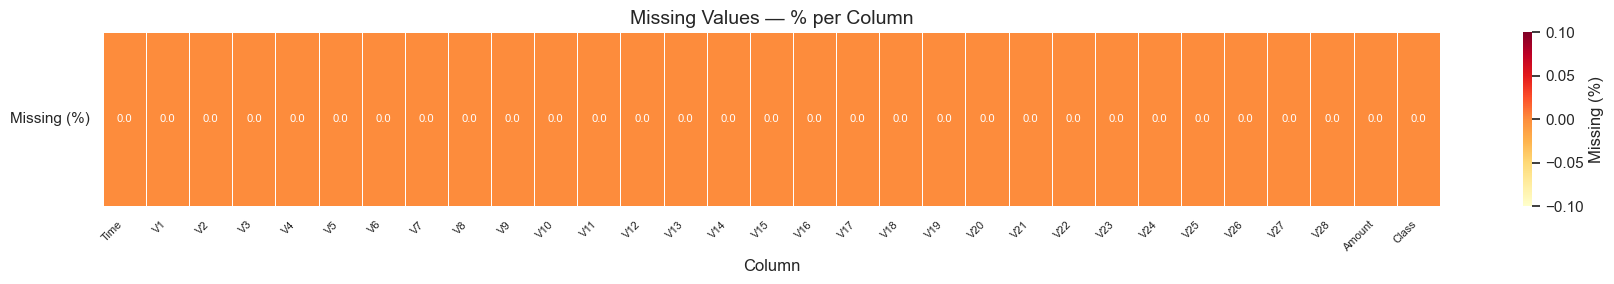

Total missing values across all columns: 0
No missing values detected.


In [ ]:
# identify missing values for all features
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(18, 3))
sns.heatmap(
    pd.DataFrame([missing_pct.values], columns=missing_pct.index),
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Missing (%)'},
    ax=ax,
)
ax.set_title('Missing Values — % per Column', fontsize=14)
ax.set_xlabel('Column')
ax.set_yticklabels(['Missing (%)'], rotation=0)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

total_missing = int(missing_count.sum())
print(f'Total missing values across all columns: {total_missing:,}')
if total_missing == 0:
    print('No missing values detected.')
else:
    print('\nColumns with missing values:')
    print(missing_count[missing_count > 0].to_string())

## 4. Feature Distributions

3×3 grid of histograms for the 9 numeric features with the highest variance.

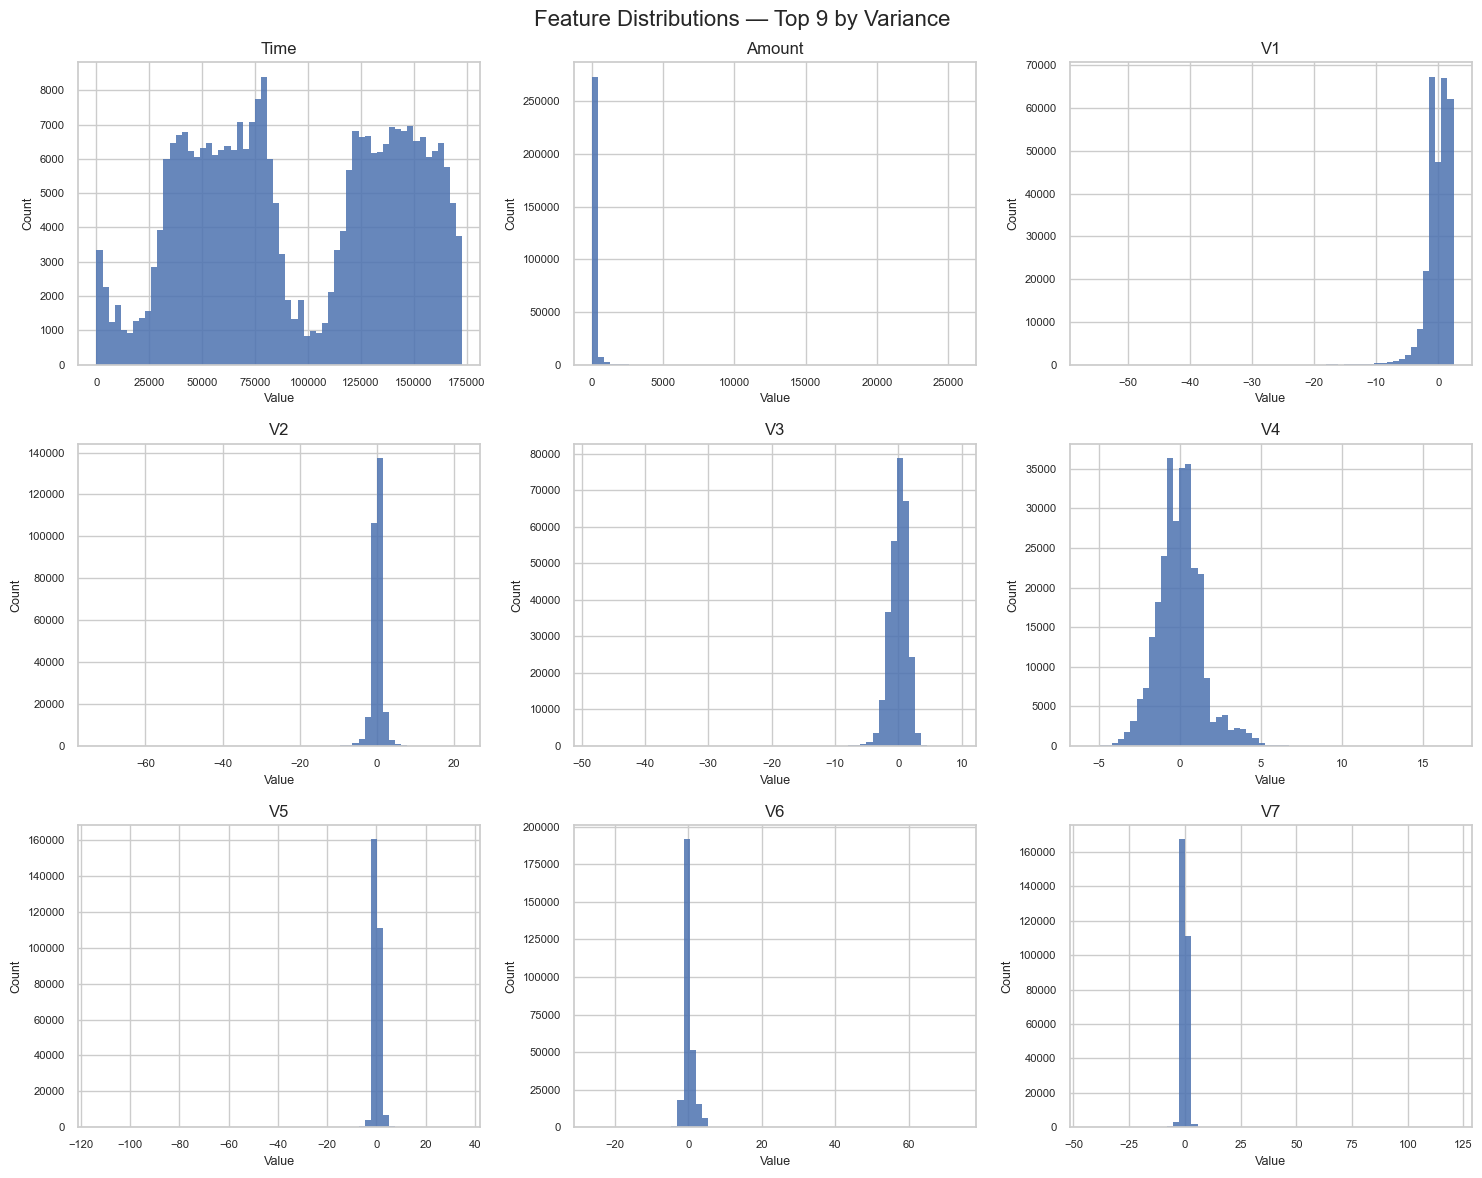

Features shown (sorted by variance, descending):
  Time: var=2255124006.2022
  Amount: var=62560.0690
  V1: var=3.8365
  V2: var=2.7268
  V3: var=2.2990
  V4: var=2.0047
  V5: var=1.9051
  V6: var=1.7749
  V7: var=1.5304


In [ ]:
# features with near-zero variance provide little information to predictive models
numeric_cols = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
# df.var() - used to calculate the unbiased variance of the values in a DataFrame
top9 = df[numeric_cols].var().nlargest(9).index.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(top9):
    axes[i].hist(df[col].dropna(), bins=60, color='#4C72B0', edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=12)
    axes[i].set_xlabel('Value', fontsize=9)
    axes[i].set_ylabel('Count',  fontsize=9)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Feature Distributions — Top 9 by Variance', fontsize=16)
plt.tight_layout()
plt.show()

# High-variance features often contain more information and tend to contribute more to predicting outcomes, 
# whereas low-variance features can be dropped to reduce computational cost and prevent overfitting

print('Features shown (sorted by variance, descending):')
for col in top9:
    print(f'  {col}: var={df[col].var():.4f}')

## 5. Correlation Matrix

Annotated lower-triangle heatmap of Pearson correlation between all numeric features (including the target).

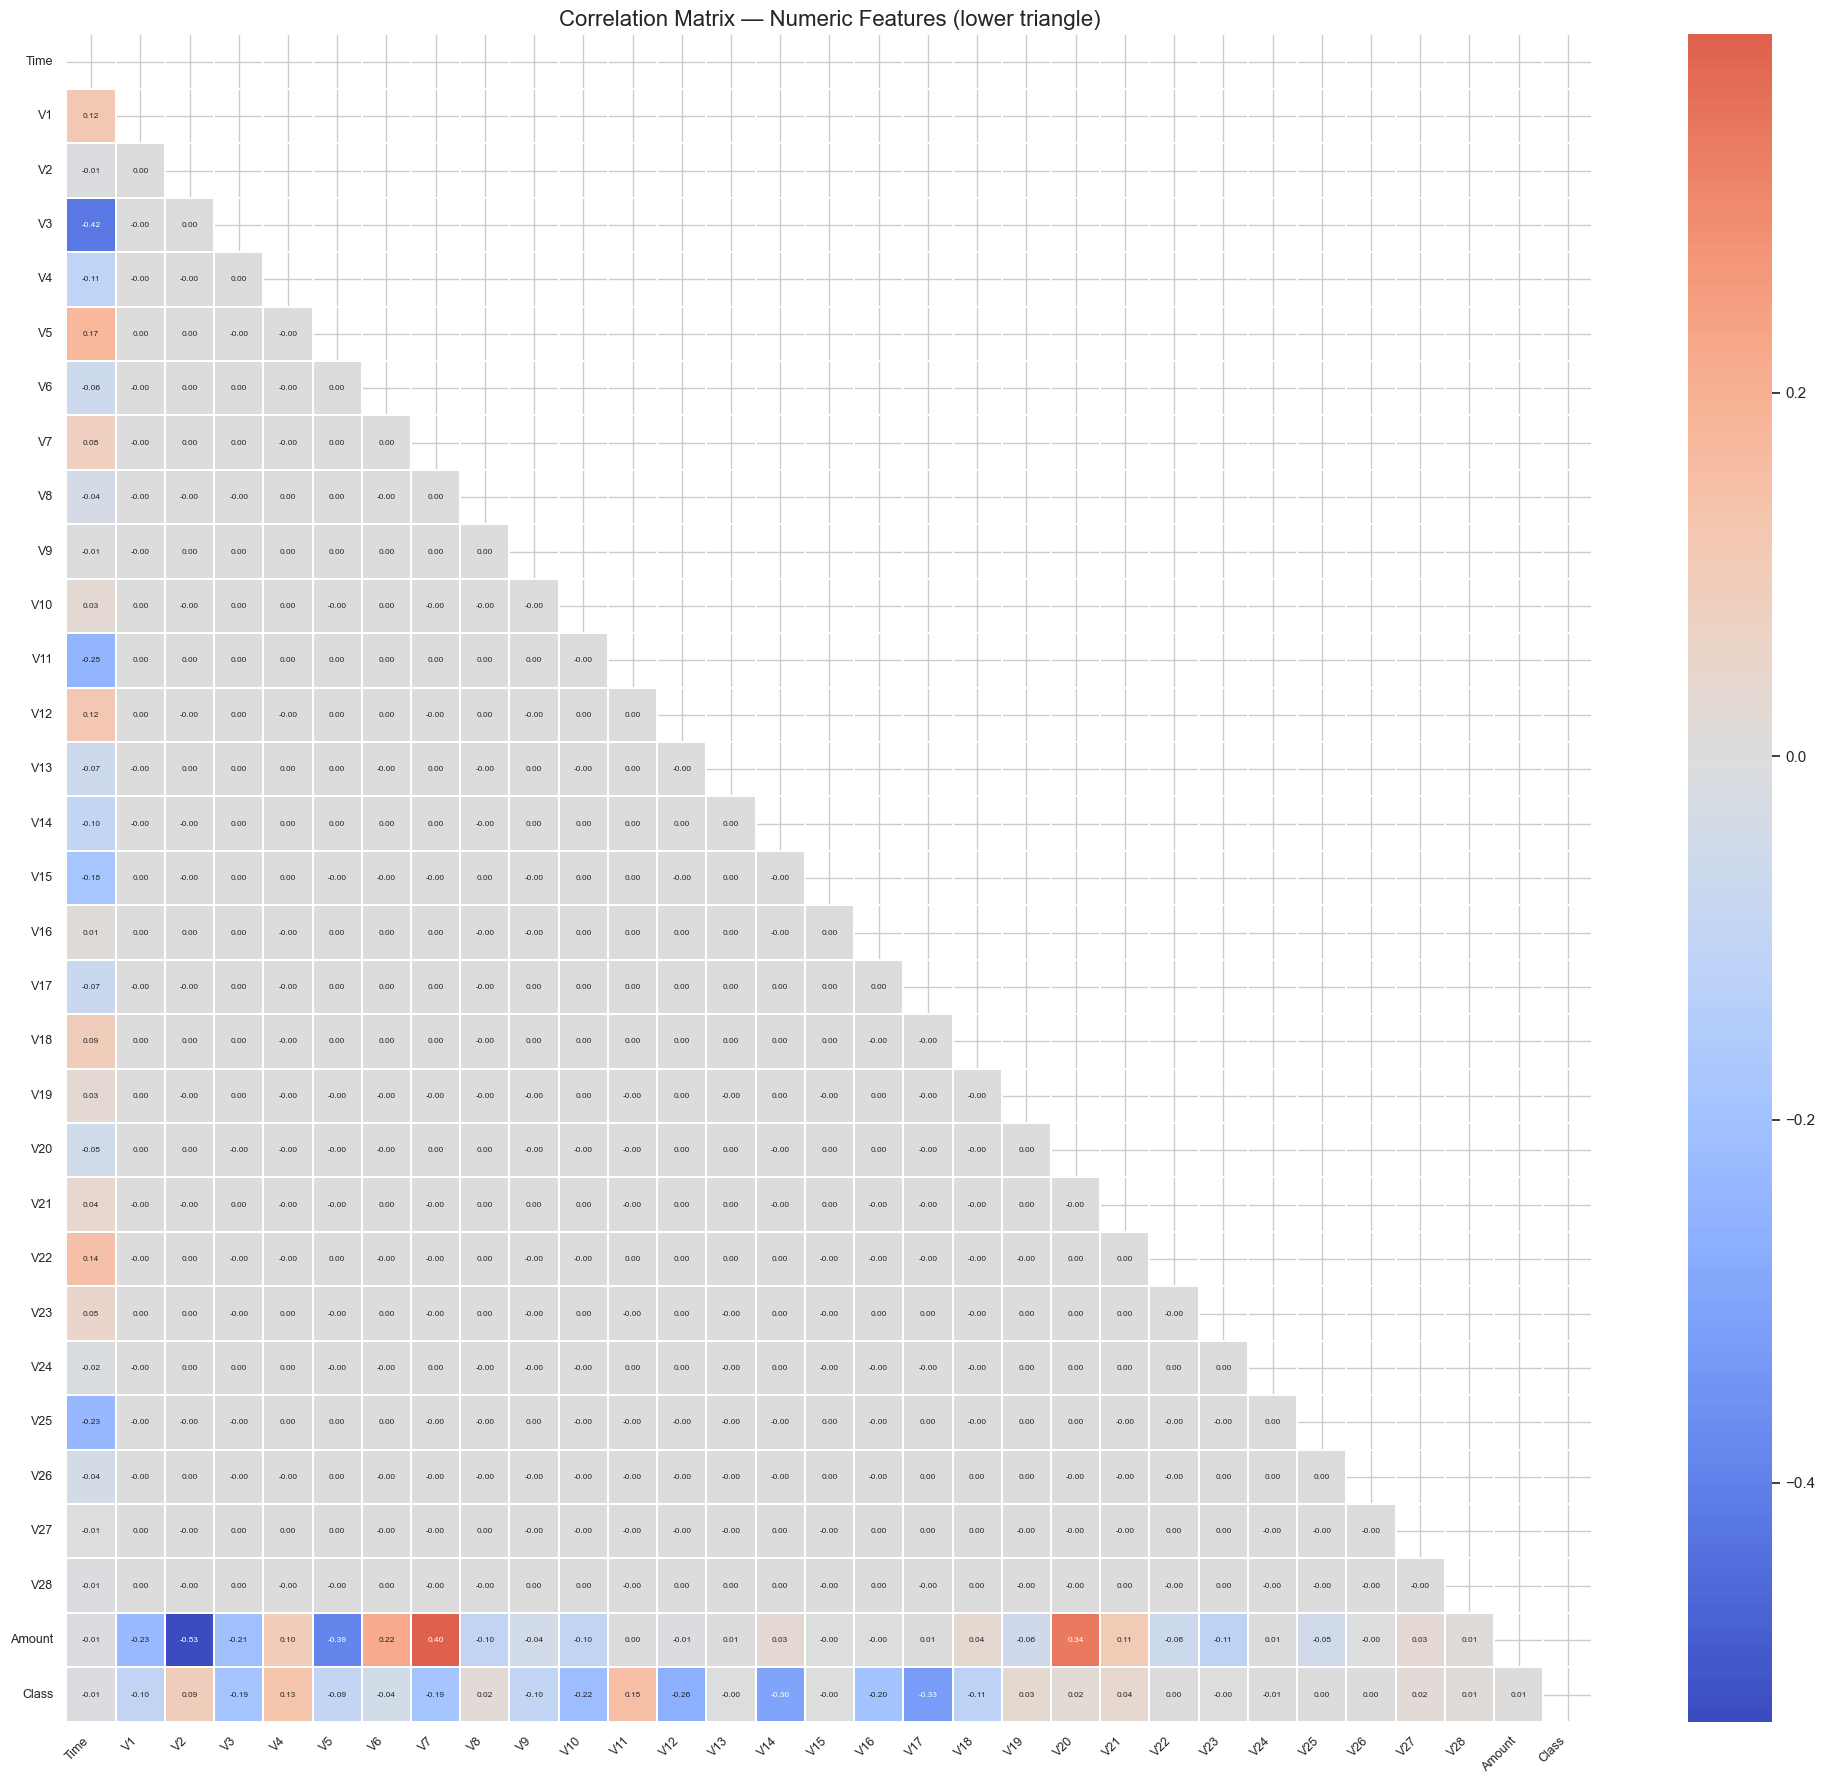

Top 10 features by |correlation| with Class:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [ ]:
# essential for quickly identifying relationships between variables by summarizing large datasets into a single, digestible view.
# Also for Multicollinearity Detection (highly correlated variables) and identify variables to remove for stability of ML model
# Identify most strongly related to the target variable, analysts can make informed decisions about which variables to include in their predictive models.
corr = df.select_dtypes(include='number').corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(20, 18))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    annot_kws={'size': 6},
    ax=ax,
)
ax.set_title('Correlation Matrix — Numeric Features (lower triangle)', fontsize=16)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

corr_target = corr[TARGET].drop(TARGET).abs().sort_values(ascending=False)
print(f'Top 10 features by |correlation| with {TARGET}:')
print(corr_target.head(10).to_string())

## 6. Features vs Target

Box plots for the 3 features most correlated with the target, split by class.

Top 3 features by |correlation| with Class: ['V17', 'V14', 'V12']


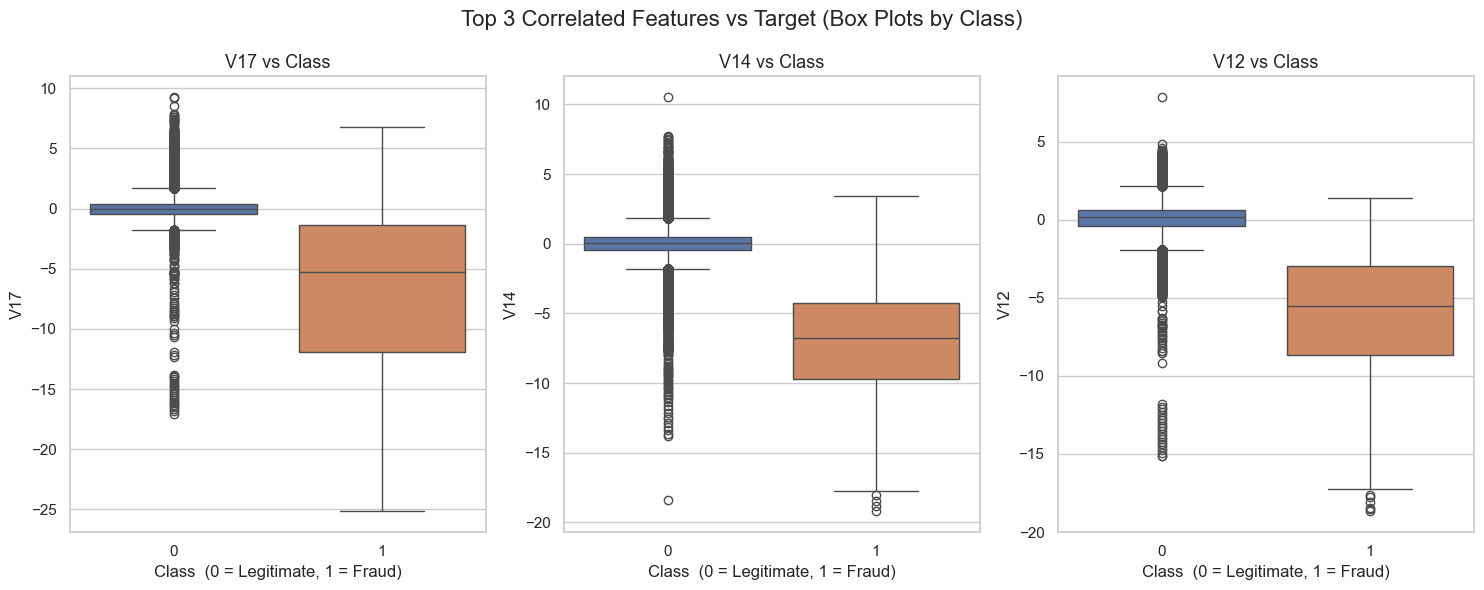

In [8]:
numeric_cols     = [c for c in df.select_dtypes(include='number').columns if c != TARGET]
# computing pairwise correlations between numeric columns dataframe and target column DataFrame or Series
corr_with_target = df[numeric_cols].corrwith(df[TARGET]).abs().sort_values(ascending=False)
# identify top 3 most correlated variables to the target
top3 = corr_with_target.head(3).index.tolist()
print(f'Top 3 features by |correlation| with {TARGET}: {top3}')

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for i, col in enumerate(top3):
    sns.boxplot(
        data=df,
        x=TARGET,
        y=col,
        ax=axes[i],
        hue=TARGET,
        palette=['#4C72B0', '#DD8452'],
        legend=False
    )
    axes[i].set_title(f'{col} vs {TARGET}', fontsize=13)
    axes[i].set_xlabel(f'{TARGET}  (0 = Legitimate, 1 = Fraud)')
    axes[i].set_ylabel(col)

plt.suptitle('Top 3 Correlated Features vs Target (Box Plots by Class)', fontsize=16)
plt.tight_layout()
plt.show()

## 7. Key Findings

- **Severe class imbalance**: Fraudulent transactions represent roughly 0.17% of all records. Accuracy is a misleading metric — optimise for AUC-PR or F1 instead; consider `class_weight='balanced'` or SMOTE applied only to the training split.
- **No missing values**: All columns are fully populated, so no imputation step is required in the cleaning pipeline.
- **Strong feature–target separability**: Several anonymised PCA features (typically V14, V17, V12, V10) show clear distributional shifts between legitimate and fraudulent transactions in the box plots — these features will likely dominate model importance.
- **`Amount` is highly right-skewed**: The transaction amount follows a long-tailed distribution with most values clustered near zero; a log-transform (`np.log1p`) before training should improve model convergence and tree-split quality.
- **PCA features are orthogonal**: V1–V28 exhibit near-zero pairwise correlations (as expected from PCA), confirming no redundancy among the anonymised features and no need for further dimensionality reduction.